In [163]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics 
import matplotlib.pyplot as plt

## df van excel bestand

In [164]:
df = pd.read_excel('AmesHousing.xlsx')
df

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


In [165]:
df = df.loc[:, ['Overall Qual','Gr Liv Area', 'SalePrice','Garage']]
df

,Overall Qual,Gr Liv Area,SalePrice,Garage
0,6,1656,215000,yes
1,5,896,105000,yes
2,6,1329,172000,yes
3,7,2110,244000,yes
4,5,1629,189900,yes
...,...,...,...,...
2925,6,1003,142500,yes
2926,5,902,131000,yes
2927,5,970,132000,no
2928,5,1389,170000,yes


## One-hot encoding

In [166]:
dummies_dataframe = pd.get_dummies(df.loc[:, ['Garage']])
dummies_dataframe.columns = ['No Garage', 'With Garage']
dummies_dataframe

,No Garage,With Garage
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
2925,False,True
2926,False,True
2927,True,False
2928,False,True


## concat nieuwe df aan originele df met dropped house style

In [167]:
df = pd.concat([df, dummies_dataframe], axis=1)
df = df.drop(['Garage'], axis=1)
df

,Overall Qual,Gr Liv Area,SalePrice,No Garage,With Garage
0,6,1656,215000,False,True
1,5,896,105000,False,True
2,6,1329,172000,False,True
3,7,2110,244000,False,True
4,5,1629,189900,False,True
...,...,...,...,...,...
2925,6,1003,142500,False,True
2926,5,902,131000,False,True
2927,5,970,132000,True,False
2928,5,1389,170000,False,True


Definieer X en y

In [168]:
X = df[['Gr Liv Area', 'SalePrice', 'No Garage', 'With Garage']]

y = df['Overall Qual']
X

,Gr Liv Area,SalePrice,No Garage,With Garage
0,1656,215000,False,True
1,896,105000,False,True
2,1329,172000,False,True
3,2110,244000,False,True
4,1629,189900,False,True
...,...,...,...,...
2925,1003,142500,False,True
2926,902,131000,False,True
2927,970,132000,True,False
2928,1389,170000,False,True


## horizontaal en verticaal snijden van tabel 

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42)

## Decision tree maken

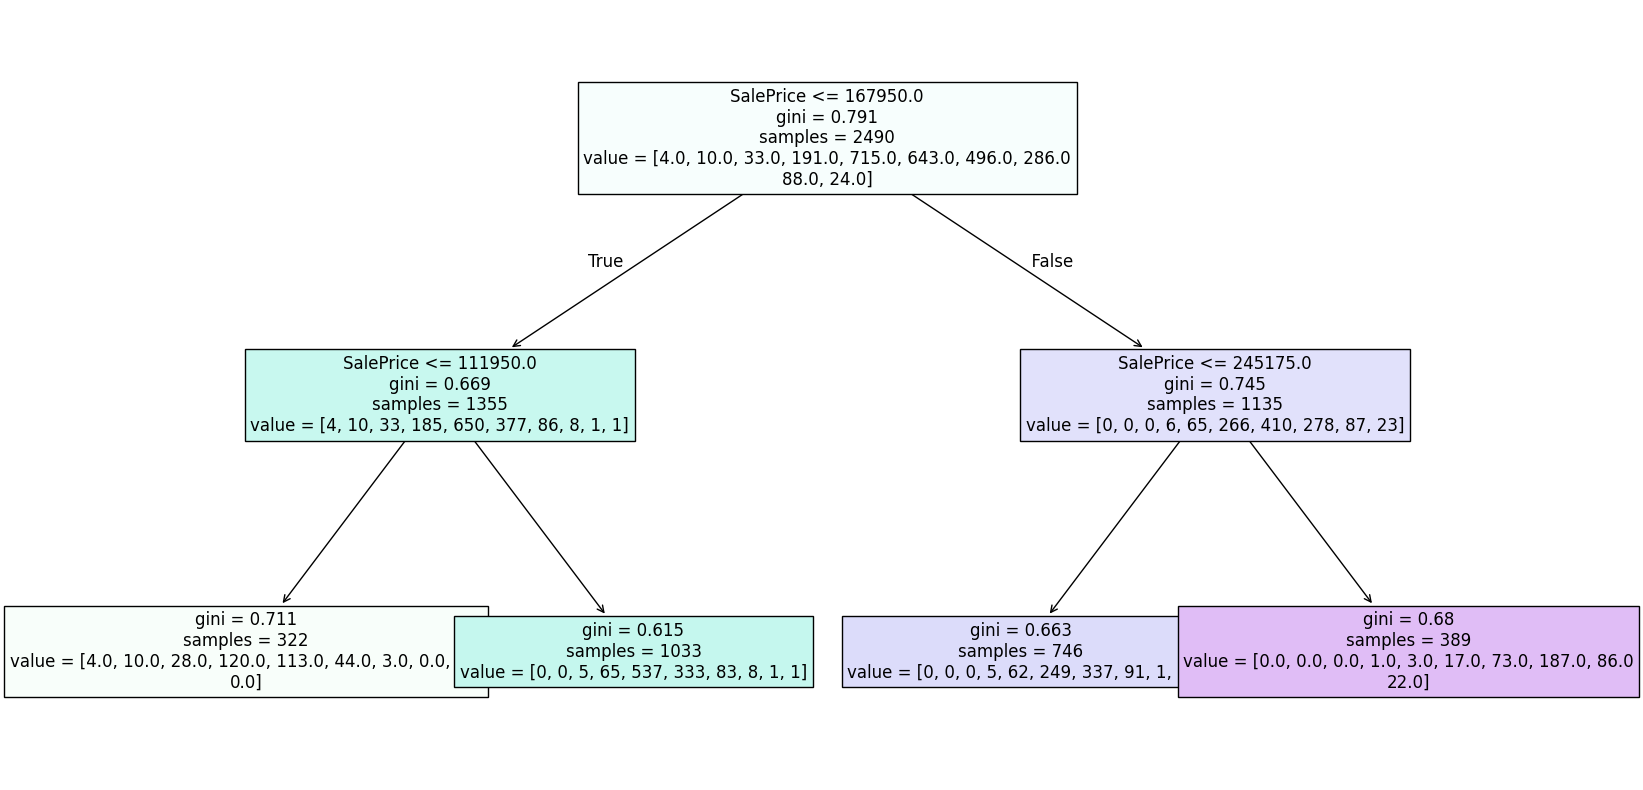

In [170]:
dtree = DecisionTreeClassifier(max_depth=2)
dtree = dtree.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
tree.plot_tree(dtree, feature_names=X.columns, fontsize=12, filled=True)
plt.show()

In [171]:
predicted_df = pd.DataFrame(dtree.predict(X_test))
predicted_df = predicted_df.rename(columns={0: 'Predicted Overall Qual'})
model_results_frame = pd.concat([y_test.reset_index(drop=True), predicted_df], axis=1)
model_results_frame

,Overall Qual,Predicted Overall Qual
0,8,5
1,6,5
2,7,7
3,4,5
4,6,5
...,...,...
435,7,8
436,5,4
437,5,5
438,6,5


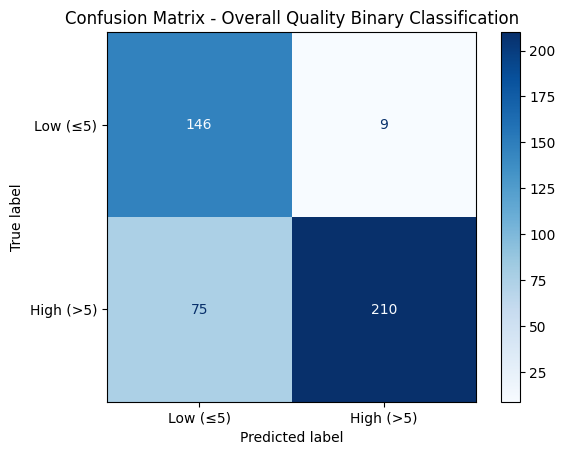

In [174]:
confusion_matrix = metrics.confusion_matrix(model_results_frame['Overall Qual'], model_results_frame['Predicted Overall Qual'])
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()